# Saigon Post-Apocalyptic Survival Predictor 🌊❄️

## 1. Project Overview
This project applies Machine Learning to predict the survival probability of individuals in Ho Chi Minh City (Saigon) after a simulated global flooding and extreme cooling catastrophe. It demonstrates a complete end-to-end data science workflow, from data generation and preprocessing to model training and prediction.

## 2. The Dataset (`saigon_survivors`)
The dataset contains 50 simulated records of survivors with the following features:
* **`district`**: The location of the survivor (e.g., District 1, Binh Thanh). *(Categorical)*
* **`body_temperature`**: Current body temperature in Celsius. *(Numerical)*
* **`supplies_left_days`**: Estimated days of food and water remaining (contains missing values to simulate real-world data). *(Numerical)*
* **`survival_skill_level`**: Categorized as Low, Medium, or High. *(Categorical)*
* **`is_alive` (Target)**: `1` means the person survived, `0` means the person perished.

The survival logic is explicitly defined in the code based on a combination of adequate supplies, high survival skills, and maintaining a stable body temperature.

## 3. Methodology
To build an automated and robust prediction system, the following data science workflow was implemented using `scikit-learn` and `xgboost`:

1.  **Data Generation:** A mock dataset was generated using `numpy` and `pandas` to simulate the post-apocalyptic scenario.
2.  **Data Imputation**: Used `SimpleImputer` to handle missing values. The mean strategy was used for numerical columns (`supplies_left_days`), and a constant 'missing' strategy was used for categorical columns.
3.  **Categorical Encoding**: Applied `OneHotEncoder` to transform text data (`district`, `survival_skill_level`) into a numerical format suitable for the machine learning model.
4.  **Pipeline Integration**: Built a Scikit-Learn `Pipeline` combined with a `ColumnTransformer` to stream the data processing and modeling phases together cleanly. This prevents data leakage and simplifies the prediction process.
5.  **Model Selection**: Trained an `XGBClassifier` (Extreme Gradient Boosting) as the primary predictive model.

## 4. Results & Evaluation
The model was evaluated using a 5-fold Cross-Validation (`cross_val_score`) approach to prevent overfitting and ensure the model's robustness.

* **Average Accuracy Score**: **82.0%**

## 5. Usage Example (Prediction)
The pipeline is set up to easily predict the fate of new individuals. For example:
* **Subject:** Nam
* **Location:** Go Vap
* **Body Temperature:** 36.5°C
* **Supplies Left:** 3 Days
* **Skill Level:** High

**AI Prediction:** => SỐNG SÓT (Alive) 🟢
*(Note: High survival skills and stable temperature saved Nam, despite low supplies).*

### Visualizations
The project includes Exploratory Data Analysis (EDA) using `seaborn` and `matplotlib`:
* **Survivor Count by District:** A bar chart illustrating the total number of survivors in different areas of Saigon.
* **Survival Status by Body Temp & Supplies Left:** A scatter plot visualizing the relationship between body temperature, remaining supplies, and the final survival status.

## 6. Conclusion
The XGBoost model, integrated within a robust Scikit-Learn pipeline, successfully predicts survival outcomes with an average accuracy of 82.0%. The model indicates that `survival_skill_level` and `supplies_left_days` are the most critical factors for surviving the extreme cold in this scenario.

---
**Libraries Used:** `numpy`, `pandas`, `scikit-learn`, `xgboost`, `matplotlib`, `seaborn`

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:

# Giữ cố định kết quả ngẫu nhiên để mỗi lần chạy không bị đổi số
np.random.seed(42)
random.seed(42)

# Khởi tạo các giá trị mẫu
districts = ['District 1', 'Binh Thanh', 'Go Vap', 'District 2', 'District 9', 'Thu Duc']
skills = ['Low', 'Medium', 'High']

# Tự động sinh 50 dòng dữ liệu
data = {
    'district': [random.choice(districts) for _ in range(50)],
    'body_temperature': np.round(np.random.uniform(34.0, 39.0, 50), 1), # Nhiệt độ từ 34.0 đến 39.0
    'supplies_left_days': [random.choice([0, 1, 2, 3, 5, 7, 10, 14, None]) for _ in range(50)], # Có chứa ô trống (None)
    'survival_skill_level': [random.choice(skills) for _ in range(50)],
}

df_saigon = pd.DataFrame(data)

# Thiết lập logic sống sót (Target y)
def determine_survival(row):
    score = 0
    # Nhiều thức ăn -> cộng điểm
    if row['supplies_left_days'] is not None and row['supplies_left_days'] > 3: 
        score += 1
    # Kỹ năng cao -> cộng điểm, Thấp -> trừ điểm
    if row['survival_skill_level'] == 'High': 
        score += 1
    elif row['survival_skill_level'] == 'Low': 
        score -= 1
    # Nhiệt độ cơ thể quá thấp (băng giá) hoặc quá cao (sốt) -> trừ điểm
    if row['body_temperature'] < 35.0 or row['body_temperature'] > 38.5: 
        score -= 1
        
    return 1 if score > 0 else 0

# Tạo cột mục tiêu
df_saigon['is_alive'] = df_saigon.apply(determine_survival, axis=1)

# Xem thử 5 dòng đầu tiên
print(df_saigon.head())

     district  body_temperature  supplies_left_days survival_skill_level  \
0     Thu Duc              35.9                 5.0                 High   
1  District 1              38.8                 0.0               Medium   
2  District 1              37.7                14.0                  Low   
3     Thu Duc              37.0                 NaN               Medium   
4      Go Vap              34.8                 1.0                  Low   

   is_alive  
0         1  
1         0  
2         0  
3         0  
4         0  


In [3]:

# ==========================================
# BƯỚC 1: NẠP DỮ LIỆU VÀ CHIA TÁCH X, y
# ==========================================
# (Thực tế sẽ dùng: df = pd.read_csv("ten_file.csv"))

# Tách riêng Mục tiêu (y) và Đặc trưng (X)
y = df_saigon['is_alive']
X = df_saigon.drop('is_alive', axis=1)

# Phân loại xem cột nào là Số, cột nào là Chữ
numerical_cols = ['body_temperature', 'supplies_left_days']
categorical_cols = ['district', 'survival_skill_level']

# ==========================================
# BƯỚC 2: CHUẨN BỊ "ĐỒ NGHỀ" DỌN DẸP
# ==========================================
# Đồ nghề cho cột SỐ: Điền số trung bình vào ô trống
numerical_transformer = SimpleImputer(strategy='mean')

# Đồ nghề cho cột CHỮ: Điền chữ "missing" vào ô trống, sau đó biến chữ thành cột số 0/1
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gom 2 bộ đồ nghề lại thành một Trạm Tiền Xử Lý (Preprocessor)
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# ==========================================
# BƯỚC 3: LẮP RÁP DÂY CHUYỀN (PIPELINE)
# ==========================================
# Chọn mô hình: Luôn bắt đầu bằng RandomForest. Khi nào tự tin thì đổi chữ RandomForestClassifier thành XGBClassifier
# model = RandomForestClassifier(n_estimators=100, random_state=42)
model = XGBClassifier(n_estimators=100, learning_rate=0.05, n_jobs=2)

# Lắp Trạm tiền xử lý và Mô hình vào chung một Dây chuyền
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# ==========================================
# BƯỚC 4: THI THỬ (CROSS-VALIDATION)
# ==========================================
# Cho dây chuyền chạy thử 5 lần (cv=5) và chấm điểm độ chính xác (accuracy)
score = cross_val_score(my_pipeline, X, y, cv=5, scoring='accuracy')

print("Điểm chính xác của từng lần thi:", score)
print("=> ĐỘ CHÍNH XÁC TRUNG BÌNH CỦA MÔ HÌNH:", score.mean() * 100, "%")

Điểm chính xác của từng lần thi: [0.9 0.7 0.9 0.8 0.8]
=> ĐỘ CHÍNH XÁC TRUNG BÌNH CỦA MÔ HÌNH: 82.0 %


# The chart illustrates the survival rate in different areas of Saigon (Bar Chart)

In [4]:
# ==========================================
# BƯỚC 1: DẠY MÔ HÌNH HỌC (FIT)
# ==========================================
# Ép toàn bộ dữ liệu X và y vào đường ống để huấn luyện chính thức
my_pipeline.fit(X, y)
# ==========================================
# BƯỚC 2: TẠO NHÂN VẬT "NAM"
# ==========================================
# Tên cột phải CHÍNH XÁC 100% với tên cột lúc huấn luyện
data_of_nam = pd.DataFrame({
    'district': ['Go Vap'],
    'body_temperature': [36.5],
    'supplies_left_days': [3],
    'survival_skill_level': ['High']
})

# ==========================================
# BƯỚC 3: PHÁN QUYẾT TỪ AI
# ==========================================
# Đưa dữ liệu của Nam chạy qua đường ống (nó sẽ tự động điền số, tự đổi chữ thành số, rồi ném vào XGBoost)
predictions = my_pipeline.predict(data_of_nam)

# ==========================================
# BƯỚC 4: IN KẾT QUẢ HIỂN THỊ
# ==========================================
print("--- KẾT QUẢ DỰ ĐOÁN SINH TỒN ---")
print(f"Nhân vật: Nam | Khu vực: Gò Vấp | Kỹ năng: Cao | Nhu yếu phẩm: 3 ngày")

if predictions[0] == 1:
    print("=> AI phán quyết: SỐNG SÓT (Alive) 🟢")
    print("Ghi chú: Kỹ năng sinh tồn Cao và nhiệt độ ổn định đã cứu mạng Nam.")
else:
    print("=> AI phán quyết: THIỆT MẠNG (Perished) 🔴")
    print("Ghi chú: Lượng thức ăn 3 ngày là không đủ để trụ vững qua đợt lạnh này.")

--- KẾT QUẢ DỰ ĐOÁN SINH TỒN ---
Nhân vật: Nam | Khu vực: Gò Vấp | Kỹ năng: Cao | Nhu yếu phẩm: 3 ngày
=> AI phán quyết: SỐNG SÓT (Alive) 🟢
Ghi chú: Kỹ năng sinh tồn Cao và nhiệt độ ổn định đã cứu mạng Nam.


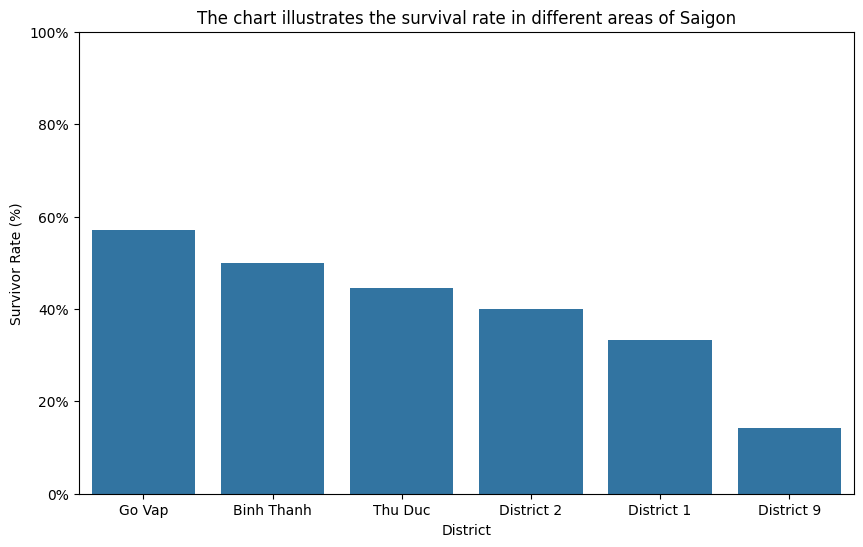

In [5]:
pd.plotting.register_matplotlib_converters()
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


# Set the width and height of the figure
plt.figure(figsize=(10,6))

# Thêm title
plt.title("The chart illustrates the survival rate in different areas of Saigon")

# Sắp xếp thứ tự các quận theo TỶ LỆ sống sót trung bình
order_mean = df_saigon.groupby('district')['is_alive'].mean().sort_values(ascending=False).index

# Vẽ biểu đồ với estimator mặc định mean bằng cách bỏ estimator
sns.barplot(x='district', y='is_alive', data=df_saigon, order=order_mean, errorbar=None)

# Tham số 1.0 báo cho máy hiểu rằng giá trị 1 tương đương với 100%
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1)

plt.xlabel('District')
plt.ylabel('Survivor Rate (%)')
plt.savefig('survivors_rate_by_district.png')

# Survival Status by Body Temp & Supplies Left (Scatter Plot)

Text(0, 0.5, 'Supplies Left (Days)')

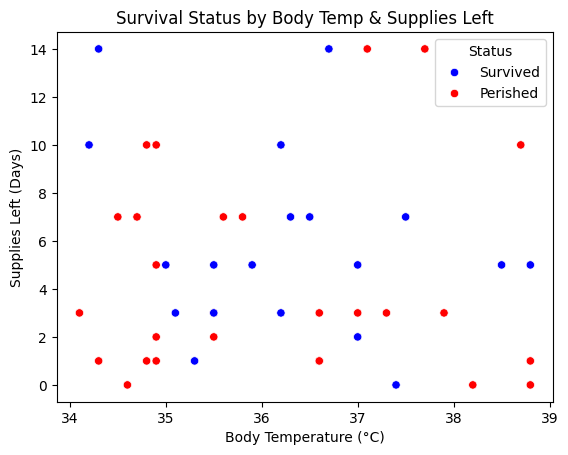

In [6]:
# Biểu đồ thể hiện mối liên hệ giữa body_temperature và supplies_left_days. 
# Màu sắc của các điểm (tham số hue) là cột is_alive đã map thành Status.
df_saigon['Status'] = df_saigon['is_alive'].map({1: 'Survived', 0: 'Perished'})

sns.scatterplot(
    x=df_saigon['body_temperature'], 
    y=df_saigon['supplies_left_days'], 
    hue=df_saigon['Status'],
    palette={'Survived': 'blue', 'Perished': 'red'})

plt.title("Survival Status by Body Temp & Supplies Left")
plt.xlabel('Body Temperature (°C)')
plt.ylabel('Supplies Left (Days)')

# Export model

In [7]:
import joblib

# Save the entire production line (including the preprocessor and the XGBoost model).
filename = 'saigon_survival_model.pkl'
joblib.dump(my_pipeline, filename)

print(f"✅ The model was successfully exported at: {filename}")

✅ The model was successfully exported at: saigon_survival_model.pkl
